In [7]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [8]:
pre_opto = ['AE_344','AE_346','AE_367']
pre_control = ['AE_350','AE_359','AE_418','AE_498','AE_351']

all_animals = np.concatenate([pre_opto, pre_control])

In [9]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3n.csv'))

In [10]:
df

,Unnamed: 0,animal,start target go rate,end target go rate,condition
0,0,AE_344,55.211589,61.716993,opto
1,1,AE_346,69.671207,54.718968,opto
2,2,AE_367,59.494561,65.697170,opto
3,3,AE_350,49.141392,39.306294,control
4,4,AE_359,50.707582,12.826748,control
5,5,AE_418,45.448545,24.919485,control
6,6,AE_498,75.000000,45.279308,control
7,7,AE_351,65.310162,37.212332,control


In [11]:
early_control_hits = []
early_opsin_hits = []
control_hits = []
opsin_hits = []

for row in df.iloc:
    early = row['start target go rate']
    end = row['end target go rate']
    if row['condition'] == 'opto':
        early_opsin_hits.append(early)
        opsin_hits.append(end)
    elif row['condition'] == 'control':
        early_control_hits.append(early)
        control_hits.append(end)

5
3
5
3
[1.92563161 2.00761299 1.96031775]
[np.float64(55.211589120518745), np.float64(69.67120729451183), np.float64(59.49456064746689)]


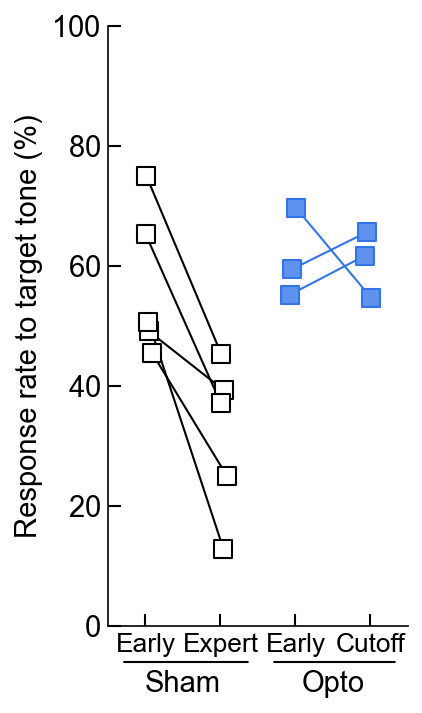

In [12]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(2, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25
meanwidth = 0.25

################################################################################################################
sz=75

control_data_early = early_control_hits#hit_early_control
opsin_data_early = early_opsin_hits#hit_early_on
control_data_cutoff = control_hits
opsin_data_cutoff = opsin_hits

print(len(control_data_early))
print(len(opsin_data_early))
print(len(control_data_cutoff))
print(len(opsin_data_cutoff))

# control_X = np.zeros_like(control_data_cutoff)#np.random.uniform(-0.25,0.25,size=len(control_data_cutoff))
# opsin_X = np.zeros_like(opsin_data_cutoff)#np.random.uniform(-0.25,0.25,size=len(opsin_data_cutoff))
control_X = np.random.uniform(-0.1,0.1,size=len(control_data_cutoff))
opsin_X = np.random.uniform(-0.1,0.1,size=len(opsin_data_cutoff))

X = control_X
Y = control_data_early
ax.scatter(X,Y,ec='k',fc='white',s=sz,marker='s',clip_on=False)
# ax.scatter(X[len(X)-2:len(X)],Y[len(Y)-2:len(Y)],color='purple',s=20,marker='s')
# ax.plot([0-meanwidth,0+meanwidth],[np.nanmedian(Y)]*2,lw=1,color='k')
# data_sem = sem(ilep.rmnan(Y))
# ax.plot([0,0],[np.nanmedian(Y)-data_sem,np.nanmedian(Y)+data_sem],lw=1,color='k')
X = control_X+1
Y = control_data_cutoff
ax.scatter(X,Y,ec='k',fc='white',s=sz,marker='s',clip_on=False)
# ax.scatter(X[len(X)-2:len(X)],Y[len(Y)-2:len(Y)],color='purple',s=20,marker='s')
# ax.plot([1-meanwidth,1+meanwidth],[np.nanmedian(Y)]*2,lw=1,color='k')
# data_sem = sem(ilep.rmnan(Y))
# ax.plot([1,1],[np.nanmedian(Y)-data_sem,np.nanmedian(Y)+data_sem],lw=1,color='k')
ax.plot([control_X,control_X+1],[control_data_early,control_data_cutoff],zorder=-10,c='k',lw=1)

X = opsin_X+2
Y = opsin_data_early
print(X)
print(Y)
ax.scatter(X,Y,ec=LASER_COLOR,fc=LIGHT_LASER,s=sz,marker='s')
# ax.plot([2-meanwidth,2+meanwidth],[np.nanmedian(Y)]*2,lw=1,color='k')
# data_sem = sem(ilep.rmnan(Y))
# ax.plot([2,2],[np.nanmedian(Y)-data_sem,np.nanmedian(Y)+data_sem],lw=1,color='k')
X = opsin_X+3
Y = opsin_data_cutoff
ax.scatter(X,Y,ec=LASER_COLOR,fc=LIGHT_LASER,s=sz,marker='s')
# ax.plot([3-meanwidth,3+meanwidth],[np.nanmedian(Y)]*2,lw=1,color='k')
# data_sem = sem(ilep.rmnan(Y))
# ax.plot([3,3],[np.nanmedian(Y)-data_sem,np.nanmedian(Y)+data_sem],lw=1,color='k')
ax.plot([opsin_X+2,opsin_X+3],[opsin_data_early,opsin_data_cutoff],zorder=-10,c=LASER_COLOR,lw=1)

################################################################################################################

labels = ['Sham','Opto']

ax.set_ylim([0,1])
ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax.set_yticks([100*d for d in [0,0.2,0.4,0.6,0.8,1]])
ylab = ax.set_ylabel('Response rate to target tone (%)')

ax.set_xlim(-0.5,3.5)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Early','Expert','Early','Cutoff'])
# colors = [GOOD_GREY,LASER_COLOR]
# [t.set_color(colors[idx]) for idx,t in enumerate(ax.xaxis.get_ticklabels())]

xtick_pos_pre = 0.5
xtick_pos_post = 2.5
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Sham', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Opto', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.04, -stdyfrac), xycoords='axes fraction', xytext=(0.48, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.54, -stdyfrac), xycoords='axes fraction', xytext=(0.97, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

### Log
# Y = 10**np.mean(np.log10(ax.get_ylim()))
# t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
# ax.plot([2.5]*2,[ax.get_ylim()[0],Y*0.45],lw=1,color=SWITCH_COLOR)
# ax.plot([2.5]*2,[ax.get_ylim()[1],Y/0.45],lw=1,color=SWITCH_COLOR)

### Linear
# Y = np.mean(ax.get_ylim())
# t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
# ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
# ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,t2]
# fig.savefig(os.path.join('D:\\\\Figures','Manuscript Figures','Opsin response rate target early vs cutoff V'+str(current_version)+'.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')
# plt.savefig(os.path.join('C:\\Users\\abrah\\Documents\\Revision Figs\\Figure 3\\Regenerated plots\\Pre Opto target early vs late cutoff with new.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [13]:
X,Y = ilep.paired_rmnan(control_data_early,control_data_cutoff)
print(f"Control: {ttest_rel(X,Y).pvalue}")
X,Y = ilep.paired_rmnan(opsin_data_early,opsin_data_cutoff)
print(f"Opsin: {ttest_rel(X,Y).pvalue}")

Control: 0.0059655659159415595
Opsin: 0.9257304776457134
